# **Earthquake Analysis**
## *EDA Notebook* 


## Objectives

* Investigate the characteristics of our values to further inform the exploratory process

* Visualise how our target features interact and how to translate that as insights to behaviour

* Last minute adjustments before carving a feature matrix 

* Hypothesis testing

## Inputs

* The cleaned 'earthquake_1995-2023_cleaned.csv'

* Libraries containing the tools needed. Pandas, numpy, matplotlib , seaborn and sk-learn.

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\NateM\\Desktop\\CI_DA\\Earthquake_Analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\NateM\\Desktop\\CI_DA\\Earthquake_Analysis'

# Import block

These are the libraries required to process and inspect the data. 


In [4]:
# Librairies needed to perform analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import scipy as stats 

And load the .csv to a dataframe 

In [5]:
# .csv to dataframe
df_clean = pd.read_csv("Dataset/Cleaned/earthquake_1995-2023_cleaned.csv")

# View the dataframe
df_clean.head(10)

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,...,continent,country,mag_depth_interaction,depth_cat,is_off_shore,high,high_severity,year,month,hour
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7,4,green,0,657,us,114,...,off_shore,Vanuatu,1254.21,Intermediate,False,0,0,2023,8,12
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8,6,yellow,0,775,us,92,...,off_shore,off_shore,453.23,shallow,True,0,0,2023,7,0
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7,5,green,0,899,us,70,...,South America,Argentina,1131.05,Intermediate,False,1,1,2023,7,3
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6,6,green,1,860,us,173,...,off_shore,off_shore,234.51,shallow,True,0,0,2023,7,6
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,0,5,unassigned,1,820,at,79,...,off_shore,off_shore,153.30,shallow,True,0,0,2023,7,6
5,"M 6.6 - 277 km NNE of Codrington, Antigua and ...",6.6,2023-07-10 20:28:00,5,4,green,1,802,us,95,...,off_shore,off_shore,66.00,shallow,True,0,0,2023,7,20
6,M 6.9 - Tonga,6.9,2023-07-02 10:27:00,4,4,green,1,741,us,136,...,off_shore,off_shore,1580.10,Intermediate,True,0,0,2023,7,10
7,M 7.2 - south of the Fiji Islands,7.2,2023-06-15 18:06:00,8,6,green,1,804,us,85,...,off_shore,off_shore,1205.31,Intermediate,True,0,0,2023,6,18
8,M 6.6 - Panama-Colombia border region,6.6,2023-05-25 03:05:00,6,6,green,1,733,us,50,...,off_shore,Colombia,66.00,shallow,False,0,0,2023,5,3
9,M 7.1 - southeast of the Loyalty Islands,7.1,2023-05-20 01:51:00,3,4,green,1,777,us,98,...,off_shore,off_shore,255.47,shallow,True,0,0,2023,5,1


---

# Section 1 - Exploration

## Univariate analysis

We're going to to take a closer look at the distributions of our data.

First we'll inspect the continuous features, magnitude and depth.

In [6]:
stat_summ = df_clean[["magnitude", "depth"]].agg(
    ["mean", "median", "min", "max", "std"]
)
print("Summary:")
print(stat_summ.round(2))

Summary:
        magnitude   depth
mean         6.94   74.61
median       6.80   29.00
min          6.50    2.70
max          9.10  670.81
std          0.44  130.81


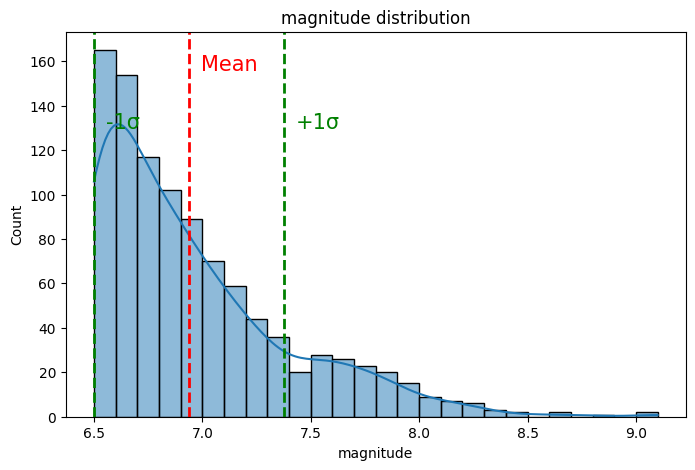

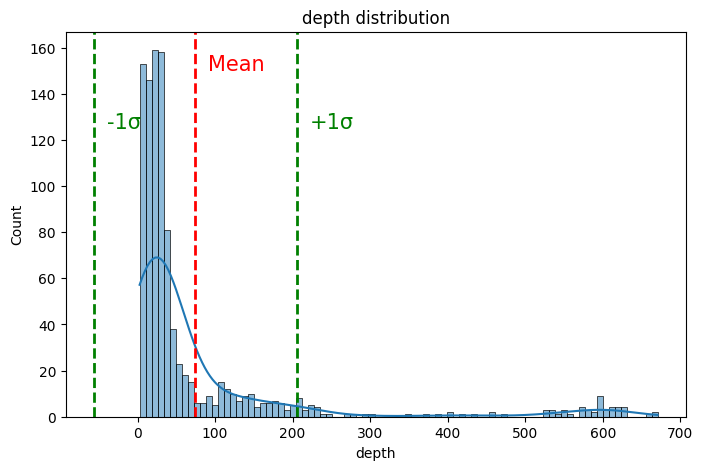

In [18]:
# Storing columns into a variable 
continuous_columns = ["magnitude", "depth"]

# Visualise them
# Method and format taken from Code Institues 
# 'Descriptive Statistics Topic 3: Variability' lesson notebook
for column in continuous_columns:
  fig, axes = plt.subplots(figsize=(8,5))
  plt.title(f"{column} distribution")
  sns.histplot(
    data=df_clean,
    x=column,
    kde=True
  )

  plt.axvline(df_clean[column].mean(), color='r', linestyle='dashed', linewidth=2)
  plt.text(x=df_clean[column].mean() + df_clean[column].std()/8 , y=axes.get_ylim()[1] * 0.90, s='Mean', fontsize=15, c='r')

  plt.axvline(df_clean[column].mean() + df_clean[column].std(), color='g', linestyle='dashed', linewidth=2)
  plt.text(x=df_clean[column].mean() + df_clean[column].std() + df_clean[column].std()/8 , y=axes.get_ylim()[1] * 0.75, s='+1σ', fontsize=15, c='g')

  plt.axvline(df_clean[column].mean() - df_clean[column].std(), color='g', linestyle='dashed', linewidth=2)
  plt.text(x=df_clean[column].mean() - df_clean[column].std() + df_clean[column].std()/8 , y=axes.get_ylim()[1] * 0.75, s='-1σ', fontsize=15, c='g')

plt.show()

Magnitude has a mean of 6.9, a median of 6.8, and a standard deviation of 0.44. The small standard deviation shows that most recorded events stay close to the average. The distribution is positively skewed, demonstrating that higher-magnitude events 7.5 or greater are rare in comparison to the mean value. Because these right-tail extremes represent valid physical disasters rather than noise, we will keep them in our dataset.

Depth has a mean of 74.61 km, a median of 29.00 km, and a standard deviation of 130.02 km. The large standard deviation and high mean relative to the median, reflects an extreme positive skew. This highlights the wide physical scale of earthquake origins, ranging from frequent shallow events in the surface crust of 0-70km, to rarer, deep-mantle subduction events reaching depths of 300km or more.


In [8]:
# # Plotting the distribution
# # Storing columns into a variable 
# continuous_columns = ["magnitude", "depth"]

# for column in continuous_columns:
#     plt.figure(figsize=(10,8)),
#     sns.histplot(
#         data=df_clean,
#         x=column,
#         bins=30,
#         kde=True
#         )
#     plt.xlabel(column)
#     plt.ylabel("Count")
#     plt.title(f"{column}")
#     plt.show()

Now for the mmi (Modified Mercalli Intensity) which is the reported local intensity .

In [9]:
stat_summ = df_clean["mmi"].agg(
    ["mean", "median", "min", "max", "std"]
)
print("mmi summary:")
print(stat_summ.round(2))

mmi summary:
mean       6.03
median     6.00
min        1.00
max       10.00
std        1.43
Name: mmi, dtype: float64


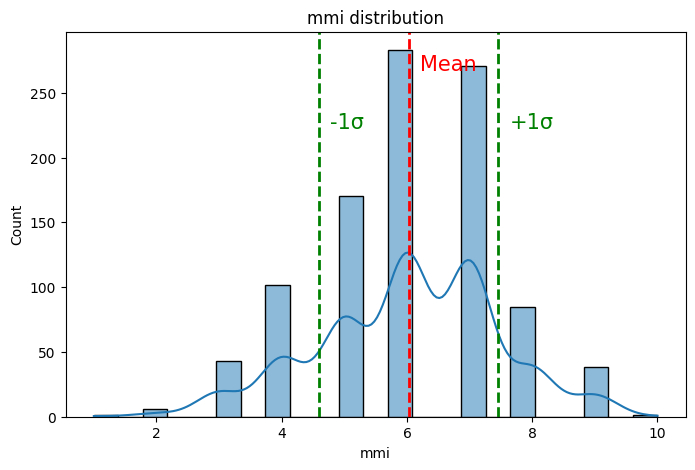

In [10]:
# Visualising distribution 
fig, axes = plt.subplots(figsize=(8,5))
plt.title("mmi distribution")
sns.histplot(
    data=df_clean,
    x="mmi",
    kde=True
  )

plt.axvline(df_clean["mmi"].mean(), color='r', linestyle='dashed', linewidth=2)
plt.text(x=df_clean["mmi"].mean() + df_clean["mmi"].std()/8 , y=axes.get_ylim()[1] * 0.90, s='Mean', fontsize=15, c='r')

plt.axvline(df_clean["mmi"].mean() + df_clean["mmi"].std(), color='g', linestyle='dashed', linewidth=2)
plt.text(x=df_clean["mmi"].mean() + df_clean["mmi"].std() + df_clean["mmi"].std()/8 , y=axes.get_ylim()[1] * 0.75, s='+1σ', fontsize=15, c='g')

plt.axvline(df_clean["mmi"].mean() - df_clean["mmi"].std(), color='g', linestyle='dashed', linewidth=2)
plt.text(x=df_clean["mmi"].mean() - df_clean["mmi"].std() + df_clean["mmi"].std()/8 , y=axes.get_ylim()[1] * 0.75, s='-1σ', fontsize=15, c='g')
plt.show()

Mmi has a mean of 6.03, a median of 6, and a standard deviation of 1.43. The close alignment between the mean and median indicates a near-normal, symmetric distribution with a modest standard deviation. This provides a balanced spread of events across the Mercalli scale (1-10), making it ideal for establishing our high-severity threshold, mmi of 7 and greater.

Now for the categorical columns.

Let's see how magnitude types and tsunami generation are split.

In [11]:
# Storing columns in a list
categorical_columns = ["magType", "tsunami"]

# Loop through list to display summary
for column in categorical_columns:
    print(f"{column} reakdown: ")
    counts = df_clean[column].value_counts(dropna=False)
    percent = df_clean[column].value_counts(normalize=True, dropna=False) * 100
    print(pd.DataFrame({"Count": counts, "Percentage ": percent.round(2)}))
    

magType reakdown: 
         Count  Percentage 
magType                    
mww        502         50.2
mwc        332         33.2
mwb        100         10.0
mw          51          5.1
Mi           5          0.5
mb           4          0.4
ms           3          0.3
md           2          0.2
ml           1          0.1
tsunami reakdown: 
         Count  Percentage 
tsunami                    
0          675         67.5
1          325         32.5


C:\Users\NateM\AppData\Local\Temp\ipykernel_13100\858377434.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\NateM\AppData\Local\Temp\ipykernel_13100\858377434.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\NateM\AppData\Local\Temp\ipykernel_13100\858377434.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["No Tsunami (67.5%)", "Tsunami (32.5%)"])


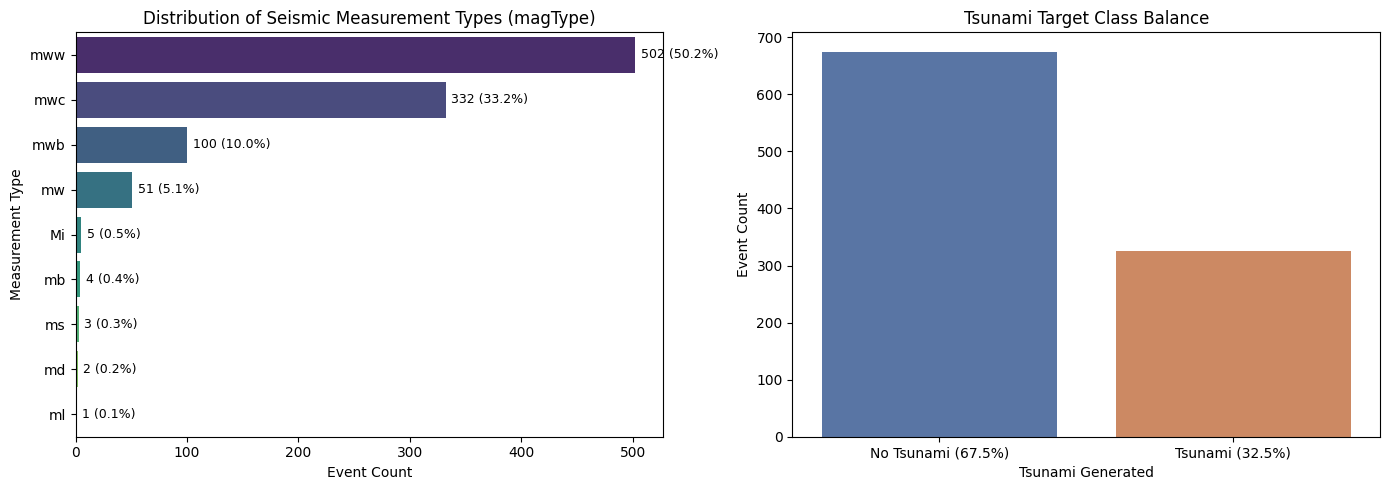

In [12]:
# Visualis the spread
# ai formatted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. magType Distribution 
mag_order = df_clean["magType"].value_counts().index
sns.countplot(
    data=df_clean,
    y="magType",
    order=mag_order,
    ax=axes[0],
    palette="viridis"
)
axes[0].set_title("Distribution of Seismic Measurement Types (magType)")
axes[0].set_xlabel("Event Count")
axes[0].set_ylabel("Measurement Type")

# Add count annotations to bars
for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(
        f"{int(width)} ({width/len(df_clean)*100:.1f}%)",
        (width + 5, p.get_y() + p.get_height() / 2),
        ha="left", va="center", fontsize=9
    )

# 2. Tsunami Class Balance (Count plot)
sns.countplot(
    data=df_clean,
    x="tsunami",
    ax=axes[1],
    palette=["#4C72B0", "#DD8452"]
)
axes[1].set_title("Tsunami Target Class Balance")
axes[1].set_xlabel("Tsunami Generated")
axes[1].set_ylabel("Event Count")
axes[1].set_xticklabels(["No Tsunami (67.5%)", "Tsunami (32.5%)"])

plt.tight_layout()
plt.show()

The vast majority of the seismic events are recorded under moment magnitude variants, with mww and mwc accounting for 83.4% of the dataset. Conversely, the mi, mb, ms, md, and ml categories each contain five or fewer instances. Because cell counts below 5 violate Chi-Square test assumptions, these low-frequency types will be grouped into a single categorey "Other", prior to evaluating Hypothesis 2

The tsunami count shows a nearly 2:1 ratio (67.5% no tsunami to 32.5% tsunami generated, representing 325 positive events). This provides a robust and balanced target distribution for non-parametric statistical testing and classification modeling.

Lastly, we'll check the longitude and latitude columns for 'Null-island Artifacts', where system errors and API failures issue 0.0,0.0 for the longitude and latitude.

In [13]:
print((df_clean["latitude"]==0.0).sum())
print((df_clean["longitude"]==0.0).sum())


0
0


We have none, so we can move onto the hypothesis testing.

---

# Section 2 - Testing H1


To test whether earthquake magnitude is independent of focal depth, we evaluate both linear and non-linear relationships. Because depth exhibits heavy right skewness, we calculate both Pearson Correlation and Spearman Rank Correlation to compare linear trends against monotonic trends.

In [14]:
# Pearson (linear) vs Spearman (rank/monotonic) correlation
pearson_corr = df_clean["magnitude"].corr(df_clean["depth"], method="pearson")
spearman_corr = df_clean["magnitude"].corr(df_clean["depth"], method="spearman")

print(f"Pearson Correlation (Magnitude vs Depth):  {pearson_corr:.3f}")
print(f"Spearman Correlation (Magnitude vs Depth): {spearman_corr:.3f}")

Pearson Correlation (Magnitude vs Depth):  0.017
Spearman Correlation (Magnitude vs Depth): 0.096


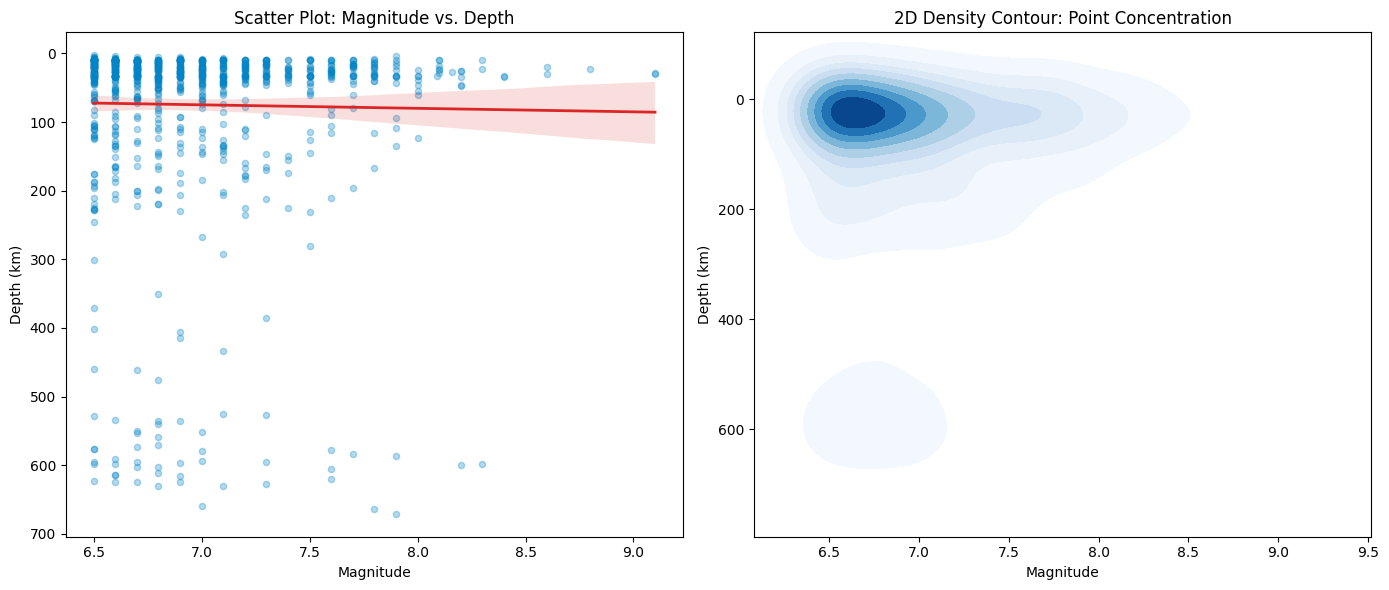

In [15]:
# Ai aided with understanding and formatting 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Scatter Plot with Regression Trendline
sns.regplot(
    data=df_clean,
    x="magnitude",
    y="depth",
    ax=axes[0],
    color="#0284c7",
    scatter_kws={"alpha": 0.3, "s": 20},
    line_kws={"color": "#dc2626", "linewidth": 2},
)
axes[0].set_title("Scatter Plot: Magnitude vs. Depth")
axes[0].set_xlabel("Magnitude")
axes[0].set_ylabel("Depth (km)")
axes[0].invert_yaxis()

# 2. 2D KDE Density Contour Plot
sns.kdeplot(
    data=df_clean,
    x="magnitude",
    y="depth",
    ax=axes[1],
    cmap="Blues",
    fill=True,
    thresh=0.05,
)
axes[1].set_title("2D Density Contour: Point Concentration")
axes[1].set_xlabel("Magnitude")
axes[1].set_ylabel("Depth (km)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

The flat regression line and negligible Pearson coefficient, r = 0.017, confirm no linear correlation between magnitude and depth. While the spread of recorded depths narrows at higher magnitudes, this reflects general event frequency, extreme magnitude earthquakes are simply rarer overall—rather than a true physical dependency. Additionally, the density contours highlight that the overwhelming majority of recorded events are concentrated in shallow-to-intermediate crustal depths, upto 200km.

---

# Section 3 - Testing H2

We know the low count magnitude types needs to grouped in a single column but let's visualise tsunami against dpeth first.

C:\Users\NateM\AppData\Local\Temp\ipykernel_13100\1111287534.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\NateM\AppData\Local\Temp\ipykernel_13100\1111287534.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No Tsunami", "Tsunami"])


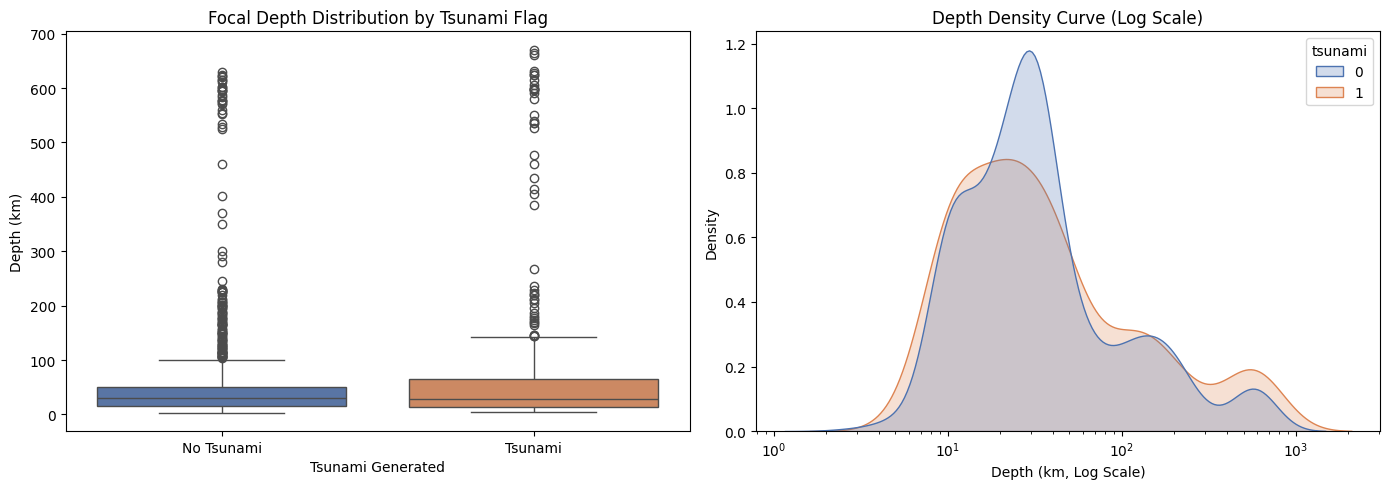

In [16]:
# Create figure layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Boxplot (Depth by Tsunami Flag)
# ai made
sns.boxplot(
    data=df_clean,
    x="tsunami",
    y="depth",
    palette=["#4C72B0", "#DD8452"],
    ax=axes[0]
)
axes[0].set_title("Focal Depth Distribution by Tsunami Flag", fontsize=12)
axes[0].set_xlabel("Tsunami Generated")
axes[0].set_ylabel("Depth (km)")
axes[0].set_xticklabels(["No Tsunami", "Tsunami"])

# 2. Log-Scaled KDE Plot (to account for right skew)
sns.kdeplot(
    data=df_clean,
    x="depth",
    hue="tsunami",
    common_norm=False,
    fill=True,
    palette=["#4C72B0", "#DD8452"],
    log_scale=True,
    ax=axes[1]
)
axes[1].set_title("Depth Density Curve (Log Scale)", fontsize=12)
axes[1].set_xlabel("Depth (km, Log Scale)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

Comparative boxplots and log-scale density curves demonstrate that tsunami and non-tsunami events share remarkably similar depth characteristics, making them innately indistinguishable on focal depth alone. Both classes group tightly within the shallow crustal range of 50–70 km—near the Earth's surface crust boundary rather than deeper subduction zones. Because near-identical medians and interquartile ranges exist across both categories, depth alone cannot serve as a decisive indicator of tsunami generation.

Now for the tests.

In [17]:
# Making the other group
top_types = ["mww", "mwc", "mwb", "mw"]
df_clean["magType_grouped"] = df_clean["magType"].apply(lambda x: x if x in top_types else "Other")

# Brackets for the Mann-whitney U Test 
tsunami_depths = df_clean[df_clean["tsunami"] == 1]["depth"]
no_tsunami_depths = df_clean[df_clean["tsunami"] == 0]["depth"]

mwu_stat, mwu_p = stats.mannwhitneyu(tsunami_depths, no_tsunami_depths, alternative="two-sided")

# Chi-Squared Test magType - tsunami
contingency_table = pd.crosstab(df_clean["magType_grouped"], df_clean["tsunami"])
chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)

print("H2 Statistical Test Results")
print(f"Mann-Whitney U Test (Depth vs Tsunami): U = {mwu_stat:.2f}, p-value = {mwu_p:.4e}")
print(f"  -> Median Depth (Tsunami = 1): {tsunami_depths.median():.2f} km")
print(f"  -> Median Depth (Tsunami = 0): {no_tsunami_depths.median():.2f} km")

print(f"\nChi-Square Test (magType vs Tsunami): Chi2 = {chi2_stat:.2f}, p-value = {chi2_p:.4e}, dof = {dof}")

AttributeError: Module 'scipy' has no attribute 'mannwhitneyu'